# Medium net experiment

Second training run: a deeper custom CNN with residual blocks and wider
channels than the base net, aiming to raise the capacity ceiling while
staying under 10M parameters. Same data pipeline and shared utilities as
the base net experiment.

## Downloading and extracting the dataset

Colab's local disk under /content is temporary, it gets wiped every time
the session restarts or disconnects, so this download and extraction
needs to run again at the start of every new session before anything
else.

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'your_token'

!pip install -q kaggle
!kaggle competitions download -c ifood-2019-fgvc6 -p /content/ifood_raw

100% 2.84G/2.84G [00:22<00:00, 134MB/s]



In [ ]:
import zipfile

extract_path = "/content/ifood/"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile("/content/ifood_raw/ifood-2019-fgvc6.zip", "r") as zf:
    zf.extractall(extract_path)

!ls -la {extract_path}

total 2993532
drwxr-xr-x 2 root root       4096 Aug  8 18:45 .
drwxr-xr-x 1 root root       4096 Aug  8 18:44 ..
-rw-r--r-- 1 root root       3717 Aug  8 18:44 class_list.txt
-rw-r--r-- 1 root root     567555 Aug  8 18:44 ifood2019_sample_submission.csv
-rw-r--r-- 1 root root     567555 Aug  8 18:44 sample_submission.csv
-rw-r--r-- 1 root root  551912960 Aug  8 18:45 test_set.zip
-rw-r--r-- 1 root root    2435315 Aug  8 18:45 train_labels.csv
-rw-r--r-- 1 root root 2277605678 Aug  8 18:45 train_set.zip
-rw-r--r-- 1 root root     222409 Aug  8 18:45 val_labels.csv
-rw-r--r-- 1 root root  232027129 Aug  8 18:45 val_set.zip


In [ ]:
for zip_name in ["train_set.zip", "val_set.zip"]:
    print("Extracting", zip_name)
    with zipfile.ZipFile(f"/content/ifood/{zip_name}", "r") as zf:
        zf.extractall("/content/ifood/")

!ls -la /content/ifood/

Extracting train_set.zip
Extracting val_set.zip
total 2997960
drwxr-xr-x 4 root root       4096 Aug  8 18:45 .
drwxr-xr-x 1 root root       4096 Aug  8 18:44 ..
-rw-r--r-- 1 root root       3717 Aug  8 18:44 class_list.txt
-rw-r--r-- 1 root root     567555 Aug  8 18:44 ifood2019_sample_submission.csv
-rw-r--r-- 1 root root     567555 Aug  8 18:44 sample_submission.csv
-rw-r--r-- 1 root root  551912960 Aug  8 18:45 test_set.zip
-rw-r--r-- 1 root root    2435315 Aug  8 18:45 train_labels.csv
drwxr-xr-x 2 root root    4091904 Aug  8 18:45 train_set
-rw-r--r-- 1 root root 2277605678 Aug  8 18:45 train_set.zip
-rw-r--r-- 1 root root     222409 Aug  8 18:45 val_labels.csv
drwxr-xr-x 2 root root     434176 Aug  8 18:45 val_set
-rw-r--r-- 1 root root  232027129 Aug  8 18:45 val_set.zip


## Loading the shared utilities

food_utils.ipynb is kept on Drive since it holds code we want to reuse
across experiments, unlike the dataset itself which stays local for
speed. FoodClassifier there supports a `scheduler_type` argument so
this notebook can use warmup + cosine annealing without affecting the
base net notebook, which keeps using its default ReduceLROnPlateau
setup.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

# path Angy
#PROJECT_DIR = "/content/drive/MyDrive/food-project"
# path K
PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/food-project"

UTILS_PATH = os.path.join(PROJECT_DIR, "food_utils.ipynb")

%run "{UTILS_PATH}"

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 40.7 MB/s eta 0:00:00


## Experiment configuration

Same data settings as the base net run, plus `warmup_epochs` for the new
scheduler. `max_epochs` is kept at the same ceiling as the base net
(150): early stopping is what actually determines how long training
runs in practice, so raising this value further wouldn't change much
unless the model kept improving well past what early stopping allows.

In [ ]:
CFG = {
    "data_dir": "/content/ifood",
    "img_size": 224,
    "batch_size": 64,
    "max_epochs": 150,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "dropout": 0.3,
    "val_frac": 0.15,
    "cap": 500,
    "num_workers": 2,
    "num_classes": 251,
    "warmup_epochs": 5,
}

for key, value in CFG.items():
    print(key, ":", value)

data_dir : /content/ifood
img_size : 224
batch_size : 64
max_epochs : 150
lr : 0.001
weight_decay : 0.0001
dropout : 0.3
val_frac : 0.15
cap : 500
num_workers : 2
num_classes : 251
warmup_epochs : 5


## Setting up the data module

This reads train_labels.csv, applies the class cap if set, and splits
into train and validation.

In [ ]:
dm = FoodDataModule(
    data_dir=CFG["data_dir"],
    img_size=CFG["img_size"],
    batch_size=CFG["batch_size"],
    val_frac=CFG["val_frac"],
    cap=CFG["cap"],
    num_workers=CFG["num_workers"],
)
dm.setup()

train images: 96326
val images: 16999
test images: 11994


## Preprocessing checks

Before building the model, checking that a batch has the expected shape
and that the augmentations look reasonable avoids debugging a model
against broken data later.

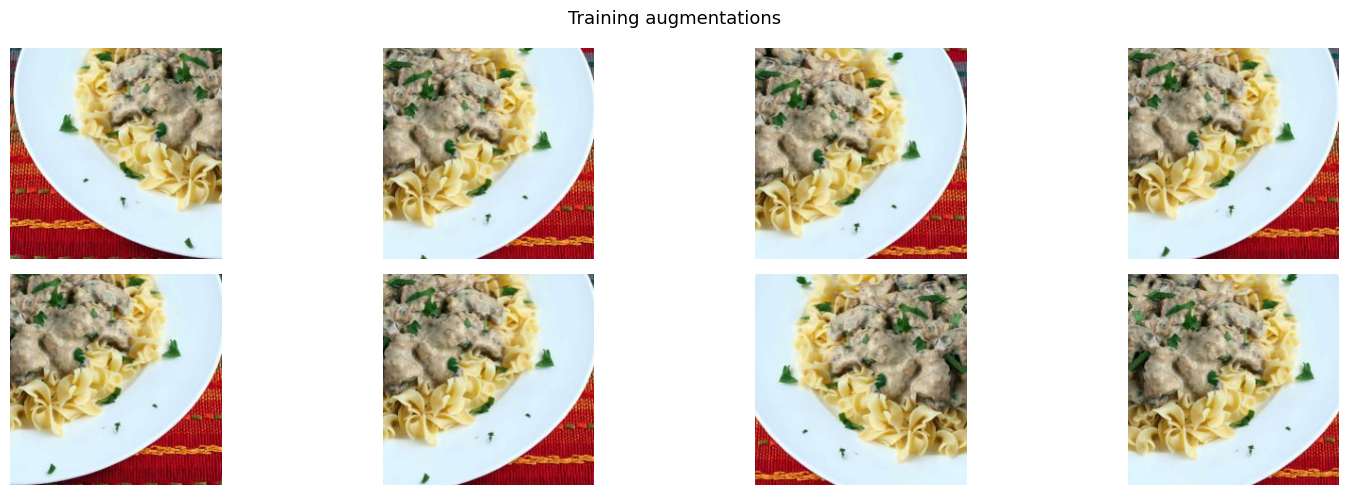

In [ ]:
sample_path = dm.train_df["path"].iloc[0]
show_augmentations(sample_path, n=8)

In [ ]:
train_loader = dm.train_dataloader()
imgs, labels = next(iter(train_loader))
print("batch shape:", imgs.shape)
print("label range:", labels.min().item(), labels.max().item())
print("pixel range:", imgs.min().item(), imgs.max().item())

batch shape: torch.Size([64, 3, 224, 224])
label range: 0 249
pixel range: -2.1179039478302 2.640000104904175


## Model architecture

Deeper than the base net: a stem, then four stages, each built around a
residual block (conv-bn-relu-conv-bn, summed with a projected skip
connection when channel count changes), followed by 2x2 max pooling for
downsampling. Wider channels than the base net (64 to 512 instead of 32
to 256). Target: comfortably under 10M parameters, verified after
building the model below.

| Stage    | Operation                                   | Output channels | Output size |
|----------|----------------------------------------------|------------------|-------------|
| Stem     | Conv 3x3 + BatchNorm + ReLU + MaxPool 2x2    | 64               | 112 x 112   |
| Stage 1  | Residual block + MaxPool 2x2                 | 64               | 56 x 56     |
| Stage 2  | Residual block (projected skip) + MaxPool 2x2| 128              | 28 x 28     |
| Stage 3  | Residual block (projected skip) + MaxPool 2x2| 256              | 14 x 14     |
| Stage 4  | Residual block (projected skip) + MaxPool 2x2| 512              | 7 x 7       |
| GAP      | Global average pooling                        | 512              | 1 x 1       |
| Dropout  | Dropout on the feature vector                 | -                | -           |
| Linear   | Fully connected to number of classes          | 251              | -           |

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)

        if in_ch != out_ch:
            self.projection = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.projection = nn.Identity()

    def forward(self, x):
        identity = self.projection(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)
        return out


class MediumCNN(nn.Module):
    def __init__(self, num_classes=251, dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.stage1 = nn.Sequential(ResidualBlock(64, 64), nn.MaxPool2d(2))
        self.stage2 = nn.Sequential(ResidualBlock(64, 128), nn.MaxPool2d(2))
        self.stage3 = nn.Sequential(ResidualBlock(128, 256), nn.MaxPool2d(2))
        self.stage4 = nn.Sequential(ResidualBlock(256, 512), nn.MaxPool2d(2))

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(p=dropout)
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.gap(x).flatten(1)
        x = self.dropout(x)
        return self.classifier(x)

## Building the model and checking the output shape

Before training anything, we run a dummy batch through the model to
confirm the shapes are correct end to end, and check the parameter count
stays under the 10M budget.

In [ ]:
model = MediumCNN(num_classes=CFG["num_classes"], dropout=CFG["dropout"])
count_parameters(model)

with torch.no_grad():
    dummy = torch.randn(2, 3, CFG["img_size"], CFG["img_size"])
    out = model(dummy)
    print("output shape:", out.shape)   # expected [2, 251]

trainable parameters: 5,026,875 (5.03M)
output shape: torch.Size([2, 251])


## Wrapping the model for Lightning

Using AdamW with a linear warmup followed by cosine annealing, instead
of the base net's Adam + ReduceLROnPlateau. This is a deeper, residual
architecture, so a short warmup helps avoid unstable early updates, and
cosine annealing was chosen to give a smooth, predictable decay instead
of one tied to a validation plateau.

The schedule below is set up assuming the full max_epochs=150 budget,
but in practice training stopped much earlier (early stopping triggered
around epoch 38), so the cosine decay never got past its early portion
before the model that ended up in the checkpoint was already trained.

In [ ]:
lit_model = FoodClassifier(
    model=model,
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"],
    optimizer_name="adamw",
    scheduler_type="cosine_warmup",
    warmup_epochs=CFG["warmup_epochs"],
)

## Callbacks and trainer setup

Same checkpoint / early stopping / CSV logging setup as the base net,
plus a LearningRateMonitor so we can see the warmup + cosine schedule in
the logs.

In [ ]:
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import CSVLogger

LOG_DIR = f"{PROJECT_DIR}/logs/medium_net"

checkpoint_cb = ModelCheckpoint(
    dirpath=f"{LOG_DIR}/checkpoints",
    filename="epoch={epoch:02d}-val_acc={val_acc:.4f}",
    monitor="val_acc",
    mode="max",
    save_top_k=2,
)

early_stop_cb = EarlyStopping(
    monitor="val_acc",
    patience=10,
    min_delta=0.005,
    mode="max",
)

lr_monitor = LearningRateMonitor(logging_interval="epoch")

logger = CSVLogger(save_dir=LOG_DIR, name="", version="")

trainer = L.Trainer(
    max_epochs=CFG["max_epochs"],
    callbacks=[checkpoint_cb, early_stop_cb, lr_monitor],
    logger=logger,
    accelerator="auto",
    log_every_n_steps=20,
)

print("device:", trainer.strategy.root_device)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


device: cuda:0


## Training

In [ ]:
trainer.fit(lit_model, datamodule=dm)

train images: 96326
val images: 16999
test images: 11994


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ MediumCNN        │  5.0 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 5.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.0 M                                                                                                
Total estimated model params size (MB): 20.107                                                                     
Modules in train mode: 52                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

## Loading the best checkpoint and evaluating on test data

In [ ]:
best_ckpt = checkpoint_cb.best_model_path
print("best checkpoint:", best_ckpt)

eval_model = MediumCNN(num_classes=CFG["num_classes"], dropout=CFG["dropout"])
best_lit_model = FoodClassifier.load_from_checkpoint(best_ckpt, model=eval_model)
best_lit_model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"

best checkpoint: /content/drive/.shortcut-targets-by-id/1ETW9S0ElOw-z28eqFj5-Yz8hKfDYZLm1/food-project/logs/medium_net/checkpoints/epoch=epoch=28-val_acc=val_acc=0.5002.ckpt


In [ ]:
test_loader = dm.test_dataloader()
y_true, y_pred = predict_all(best_lit_model.model, test_loader, device=device)

metrics = evaluate(y_true, y_pred, verbose=True)

metrics["experiment"] = "medium_net"
metrics["config"] = CFG

import json
os.makedirs(LOG_DIR, exist_ok=True)
with open(f"{LOG_DIR}/metrics_summary.json", "w") as f:
    json.dump(metrics, f, indent=2)

accuracy : 0.5778
macro_precision : 0.5865
macro_recall : 0.5644
macro_f1 : 0.5608
weighted_f1 : 0.5769


Solid jump from BaseNet, roughly +4.7 points on accuracy, +5.5 on F1 macro. Precision sits a bit above recall (0.5865 vs 0.5644), which fits what we saw in the confusion matrix, the model's pretty confident on the classes it knows well but still whiffs on the hard ones like welsh rarebit and marble cake, so recall takes the bigger hit.

Weighted F1 (0.5769) landing close to plain accuracy (0.5778) means the big classes aren't just carrying the score while everything else tanks, macro numbers back that up too.

This is the checkpoint from epoch 28, right before val started drifting back up.

## Training curves and confusion matrix

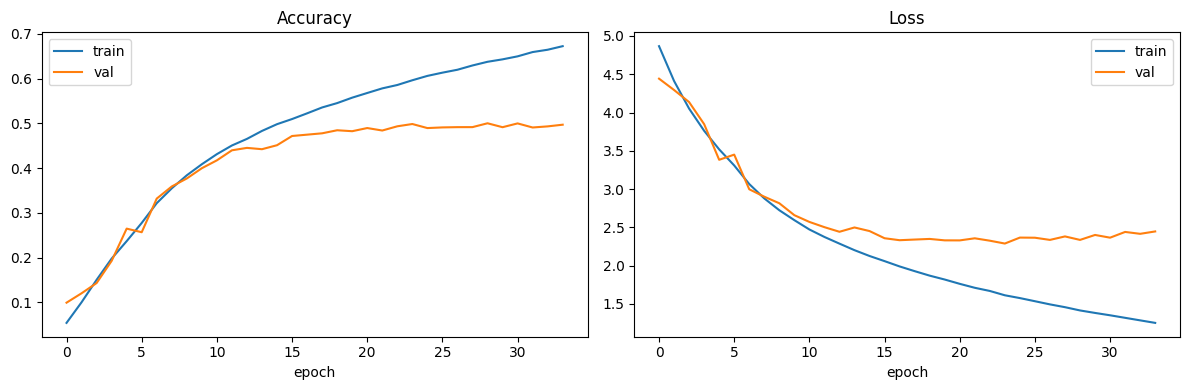

In [ ]:
plot_training_curves(LOG_DIR)

Train keeps climbing past 0.65 while val flatlines around 0.49-0.50 from epoch 15 onward, basically frozen after that. Loss makes it even clearer: train drops all the way to 1.3, but val actually ticks back up after its low point near epoch 16, going from about 2.3 to 2.4. So this isn't just a plateau, the model is genuinely overfitting.

Training stopped around epoch 33, which matches the epoch 28 checkpoint plus 10 epochs of patience. That means the cosine schedule had barely started coming down from its post-warmup peak by the time overfitting was already underway. Jumping from 1M to 5M params without touching dropout or augmentation gave the network enough room to start memorizing the train set before the learning rate ever got low enough to help.

This is a good comparison: BaseNet barely fits and trains clean, MediumNet overfits earlier and more obviously. Feeds right into the hyperparameter tuning experiment, bumping dropout or weight decay on MediumNet to see if that gap closes.

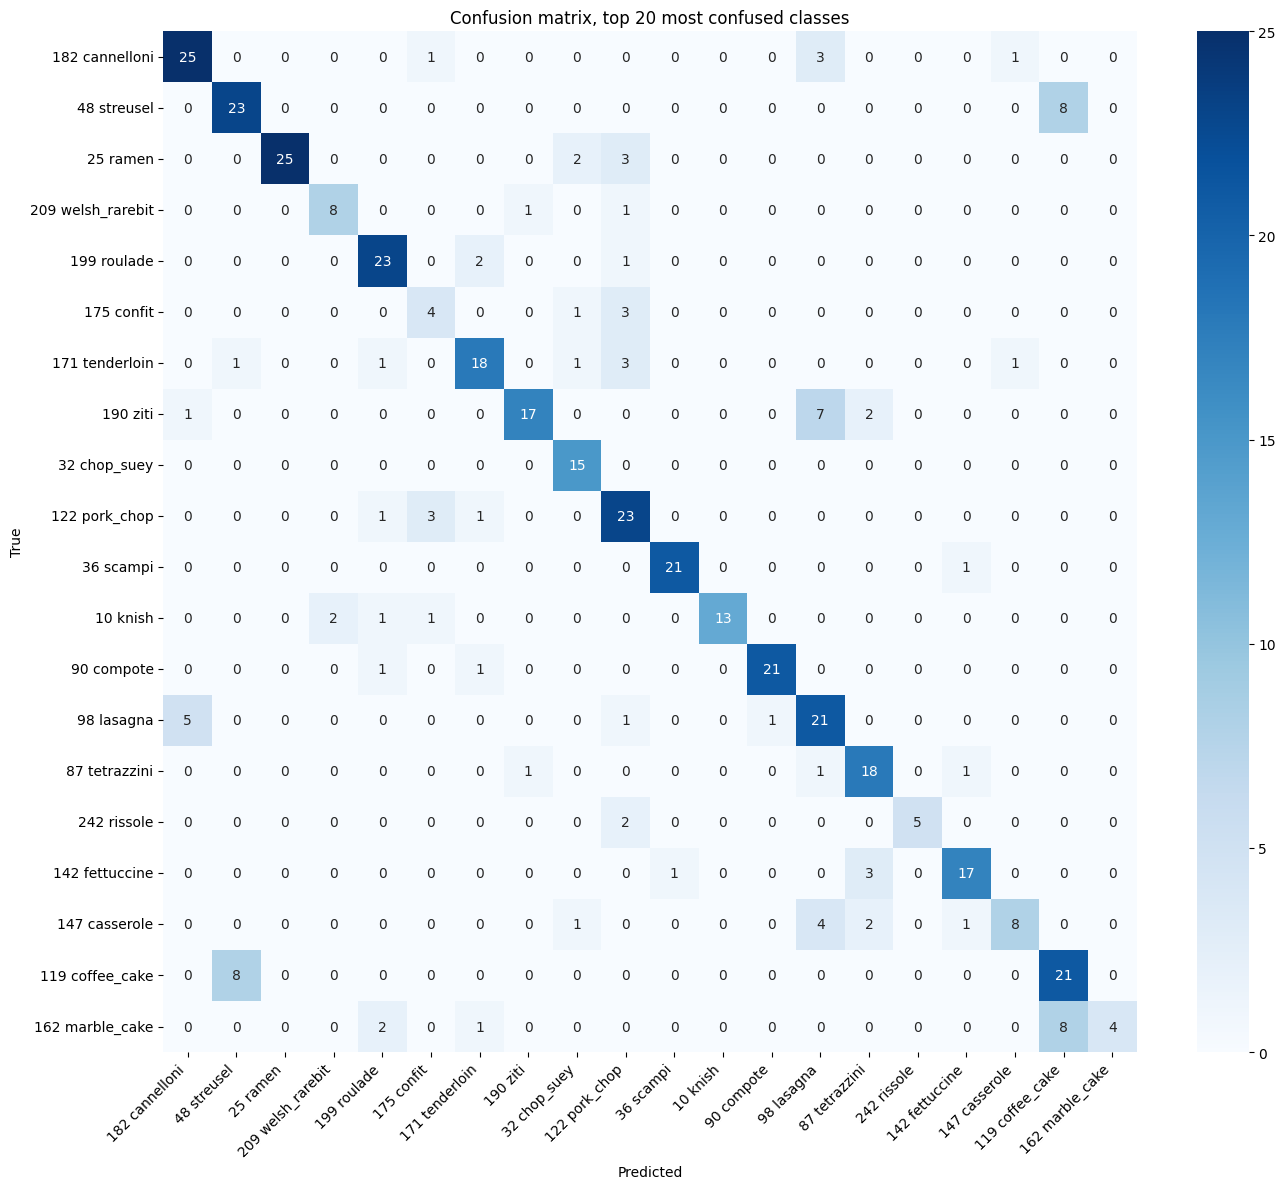

In [ ]:
class_names_path = f"{CFG['data_dir']}/class_list.txt"
class_names = None
if os.path.exists(class_names_path):
    with open(class_names_path) as f:
        class_names = [line.strip() for line in f.readlines()]

plot_confusion_matrix(y_true, y_pred, class_names=class_names, top_n=20)

Diagonal's strong for most classes here, better separation overall than BaseNet. Cannelloni, ramen, roulade, scampi, compote all sit clean at 20+ with almost nothing bleeding out.

Streusel and coffee cake are stuck together though, 8 streusel samples predicted as coffee cake and nothing going the other way. Both are baked, crumbly, similar tone, so that's an understandable mix-up. Marble cake is still a mess, same pattern as BaseNet, most of its mass goes to coffee cake (8) with only 4 landing correctly, so more capacity didn't fix that one at all, which tracks with it being a low-data class from the start. Ziti also spreads out a bit toward lasagna and tetrazzini, three pasta-in-sauce dishes that probably look nearly identical from a phone photo.

Welsh rarebit stands out as the weakest diagonal in this whole set, only 8 out of roughly 12, scattered into confit, tenderloin and pork chop. Given it was already near the bottom for BaseNet too, this looks like a genuinely hard class rather than something extra capacity alone fixes.

In [ ]:
per_class_df = per_class_metrics(y_true, y_pred, class_names=class_names)
plot_worst_classes(per_class_df, n=15)
per_class_df.head(15)

In [ ]:
# Unassign the runtime in order to not waste paid computing units
from google.colab import runtime
runtime.unassign()